In [8]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/anikajha05/doe-electric-disturbance-events/DOE_Electric_Disturbance_Events.xlsx


In [9]:
import pandas as pd

df = pd.read_excel("/kaggle/input/datasets/anikajha05/doe-electric-disturbance-events/DOE_Electric_Disturbance_Events.xlsx")

print(df.head())
print(df.columns)
print(df.info())

            Table B.2. Major Disturbances and Unusual Occurrences, 2002  \
0                  NaN                                              NaN   
1                 Date                                      NERC Region   
2              January                                              NaN   
3  2002-01-30 00:00:00                                              SPP   
4                  NaN                                              NaN   

  Unnamed: 2 Unnamed: 3           Unnamed: 4        Unnamed: 5  \
0        NaN        NaN                  NaN               NaN   
1       Time       Area  Type of Disturbance  Loss (megawatts)   
2        NaN        NaN                  NaN               NaN   
3   06:00:00   Oklahoma            Ice Storm               500   
4        NaN        NaN                  NaN               NaN   

                     Unnamed: 6           Unnamed: 7  
0                           NaN                  NaN  
1  Number of Customers Affected     Restor

In [10]:
import pandas as pd

df = pd.read_excel("/kaggle/input/datasets/anikajha05/doe-electric-disturbance-events/DOE_Electric_Disturbance_Events.xlsx", header=1)

print(df.head())
print(df.columns)

            Unnamed: 0   Unnamed: 1 Unnamed: 2                     Unnamed: 3  \
0                 Date  NERC Region       Time                           Area   
1              January          NaN        NaN                            NaN   
2  2002-01-30 00:00:00          SPP   06:00:00                       Oklahoma   
3                  NaN          NaN        NaN                            NaN   
4  2002-01-29 00:00:00          SPP    Evening  Metropolitan Kansas City Area   

            Unnamed: 4        Unnamed: 5                    Unnamed: 6  \
0  Type of Disturbance  Loss (megawatts)  Number of Customers Affected   
1                  NaN               NaN                           NaN   
2            Ice Storm               500                       1881134   
3                  NaN               NaN                           NaN   
4            Ice Storm           500-600                        270000   

            Unnamed: 7  
0     Restoration Time  
1                 

In [11]:
import pandas as pd

df = pd.read_excel("/kaggle/input/datasets/anikajha05/doe-electric-disturbance-events/DOE_Electric_Disturbance_Events.xlsx", header=1)

# Drop first useless row (January row)
df = df.drop(0)

# Reset index
df = df.reset_index(drop=True)

print(df.head())
print(df.columns)

            Unnamed: 0 Unnamed: 1 Unnamed: 2                     Unnamed: 3  \
0              January        NaN        NaN                            NaN   
1  2002-01-30 00:00:00        SPP   06:00:00                       Oklahoma   
2                  NaN        NaN        NaN                            NaN   
3  2002-01-29 00:00:00        SPP    Evening  Metropolitan Kansas City Area   
4  2002-01-30 00:00:00        SPP   16:00:00                       Missouri   

  Unnamed: 4 Unnamed: 5 Unnamed: 6           Unnamed: 7  
0        NaN        NaN        NaN                  NaN  
1  Ice Storm        500    1881134  2002-02-07 12:00:00  
2        NaN        NaN        NaN                  NaN  
3  Ice Storm    500-600     270000                  NaN  
4  Ice Storm        210      95000  2002-02-10 21:00:00  
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')


In [20]:
import pandas as pd

df = pd.read_excel("/kaggle/input/datasets/anikajha05/doe-electric-disturbance-events/DOE_Electric_Disturbance_Events.xlsx", header=1)

# Drop first useless row (January row)
df = df.drop(0)

# Reset index
df = df.reset_index(drop=True)

print(df.head())
print(df.columns)

            Unnamed: 0 Unnamed: 1 Unnamed: 2                     Unnamed: 3  \
0              January        NaN        NaN                            NaN   
1  2002-01-30 00:00:00        SPP   06:00:00                       Oklahoma   
2                  NaN        NaN        NaN                            NaN   
3  2002-01-29 00:00:00        SPP    Evening  Metropolitan Kansas City Area   
4  2002-01-30 00:00:00        SPP   16:00:00                       Missouri   

  Unnamed: 4 Unnamed: 5 Unnamed: 6           Unnamed: 7  
0        NaN        NaN        NaN                  NaN  
1  Ice Storm        500    1881134  2002-02-07 12:00:00  
2        NaN        NaN        NaN                  NaN  
3  Ice Storm    500-600     270000                  NaN  
4  Ice Storm        210      95000  2002-02-10 21:00:00  
Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7'],
      dtype='object')


In [21]:
import pandas as pd

# Load with correct header
df = pd.read_excel("/kaggle/input/datasets/anikajha05/doe-electric-disturbance-events/DOE_Electric_Disturbance_Events.xlsx", header=1)

# ❌ Remove junk rows (like "January")
df = df[df["Unnamed: 0"] != "January"]

# Reset index
df = df.reset_index(drop=True)

# ✅ Rename columns
df.columns = [
    "Date", "NERC_Region", "Time", "Area",
    "Disturbance_Type", "Demand_Loss_MW",
    "Customers_Affected", "Restoration_Time"
]

# ✅ Convert date
df["Date"] = pd.to_datetime(df["Date"], errors='coerce')

# Remove invalid rows
df = df.dropna(subset=["Date"])

# Extract features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

# ✅ Fix demand loss (handle ranges like 500-600)
def clean_loss(x):
    if isinstance(x, str) and '-' in x:
        a, b = x.split('-')
        return (float(a) + float(b)) / 2
    return pd.to_numeric(x, errors='coerce')

df["Demand_Loss_MW"] = df["Demand_Loss_MW"].apply(clean_loss)

# Final check
print(df.head())
print(df.info())

        Date NERC_Region      Time                           Area  \
1 2002-01-30         SPP  06:00:00                       Oklahoma   
3 2002-01-29         SPP   Evening  Metropolitan Kansas City Area   
4 2002-01-30         SPP  16:00:00                       Missouri   
6 2002-02-27        WSCC  10:48:00                     California   
8 2002-03-09        ECAR  00:00:00    Lower Peninsula of Michigan   

            Disturbance_Type  Demand_Loss_MW Customers_Affected  \
1                  Ice Storm           500.0            1881134   
3                  Ice Storm           550.0             270000   
4                  Ice Storm           210.0              95000   
6  Interruption of Firm Load           300.0             255000   
8             Severe Weather           190.0             190000   

      Restoration_Time  Year  Month  
1  2002-02-07 12:00:00  2002      1  
3                  NaN  2002      1  
4  2002-02-10 21:00:00  2002      1  
6  2002-02-27 11:35:00  2002  

/tmp/ipykernel_55/2428582267.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors='coerce')


NameError: name 'plt' is not defined

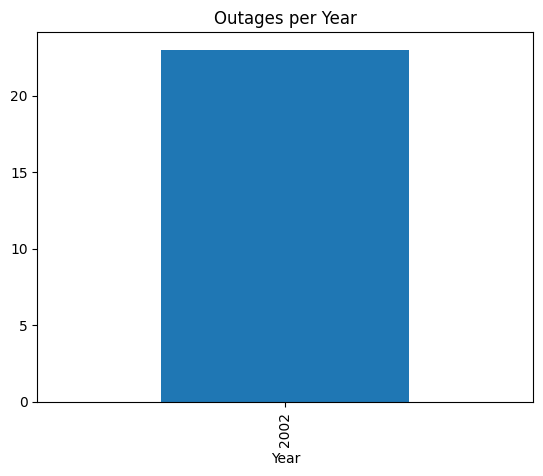

In [22]:
df.groupby("Year").size().plot(kind='bar', title="Outages per Year")
plt.show()

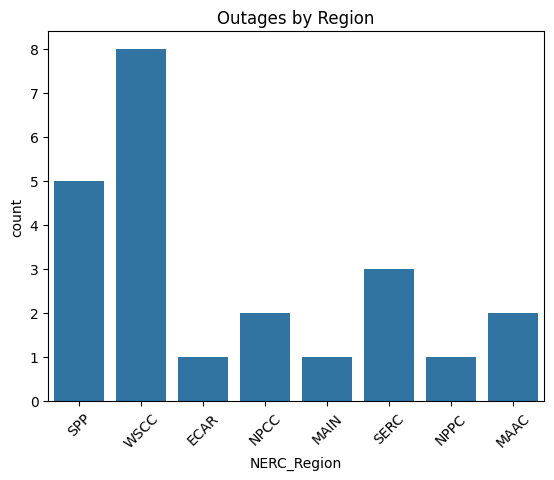

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="NERC_Region")
plt.title("Outages by Region")
plt.xticks(rotation=45)
plt.show()

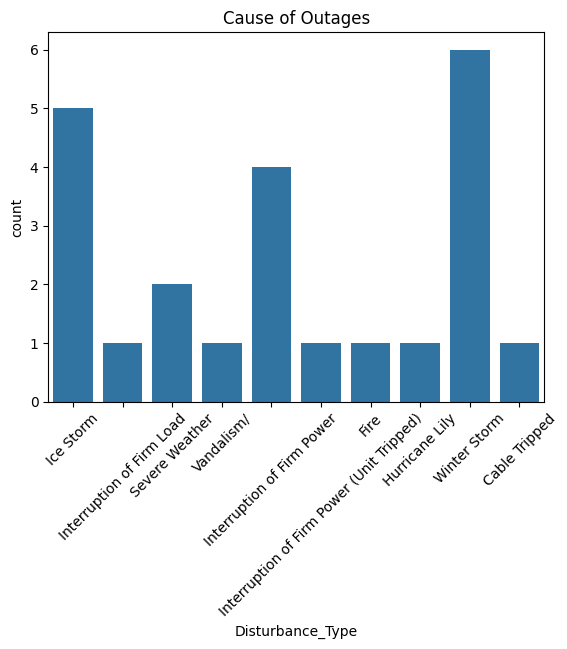

In [24]:
sns.countplot(data=df, x="Disturbance_Type")
plt.xticks(rotation=45)
plt.title("Cause of Outages")
plt.show()

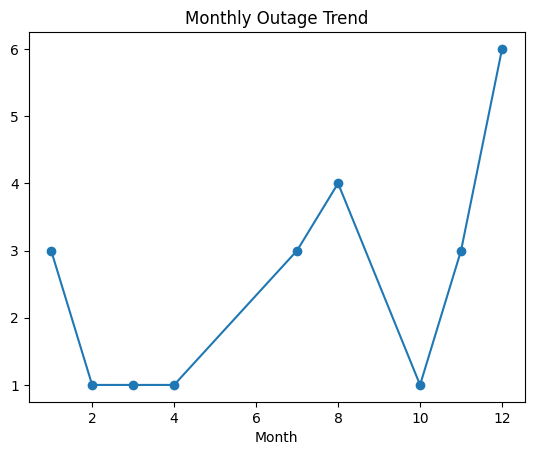

In [25]:
df.groupby("Month").size().plot(marker='o', title="Monthly Outage Trend")
plt.show()

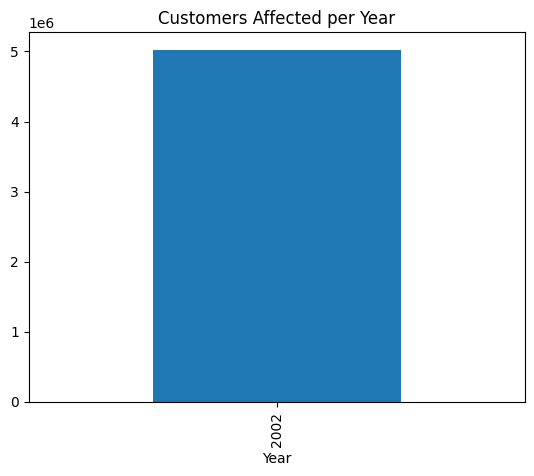

In [26]:
df["Customers_Affected"] = pd.to_numeric(df["Customers_Affected"], errors='coerce')

df.groupby("Year")["Customers_Affected"].sum().plot(kind='bar', title="Customers Affected per Year")
plt.show()

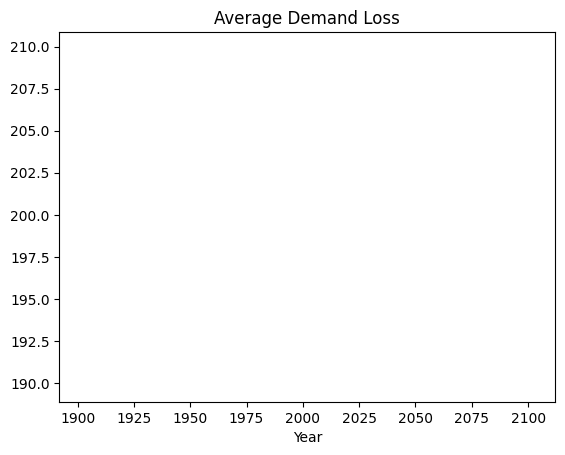

In [27]:
df.groupby("Year")["Demand_Loss_MW"].mean().plot(title="Average Demand Loss")
plt.show()

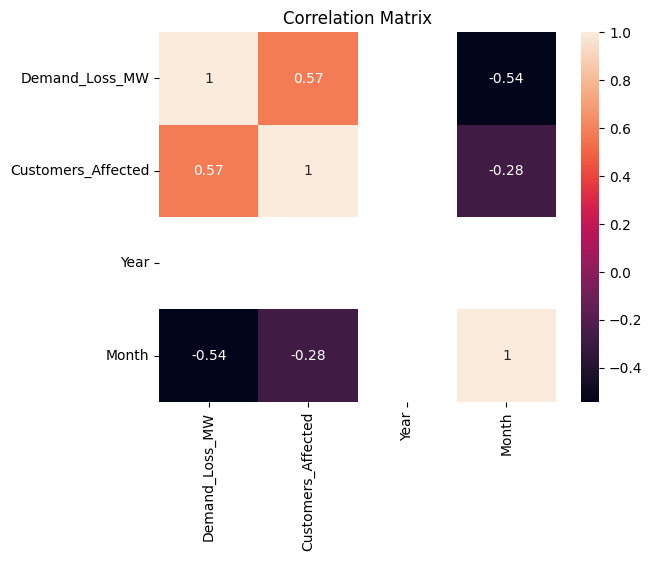

In [28]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()